In [43]:
import mne
from moabb.datasets import Forenzo2023

In [44]:
import os


subject_id = 1


# if Forenzo2023_subject_1_raw.fif already exists, we can load it directly  or download and process the data from the Forenzo2023 dataset
if os.path.exists(f'Forenzo2023_subject_{subject_id}_raw.fif'):
    raw = mne.io.read_raw_fif(f'Forenzo2023_subject_{subject_id}_raw.fif', preload=True)
    print(f"Loaded raw data from Forenzo2023_subject_{subject_id}_raw.fif")
else:
    dataset = Forenzo2023()
    data = dataset.get_data(subjects=[subject_id])
    print(data[subject_id])
    raw = data[subject_id]["0"]["0"]
    
# /Users/remy.benmessaoud/mne_data/MNE-forenzo2023-data/Subject01/publicData


Opening raw data file Forenzo2023_subject_1_raw.fif...


Isotrak not found
    Range : 0 ... 163879 =      0.000 ...   163.879 secs
Ready.
Reading 0 ... 163879  =      0.000 ...   163.879 secs...
Loaded raw data from Forenzo2023_subject_1_raw.fif


In [45]:

# save the raw data to a .fif file for faster loading in the future
raw.save(f'Forenzo2023_subject_{subject_id}_raw.fif', overwrite=True)

Overwriting existing file.
Writing /Users/remy.benmessaoud/Documents/python_projects/smc_rnns-main/rbm_stuff/Forenzo2023_subject_1_raw.fif
Overwriting existing file.
Closing /Users/remy.benmessaoud/Documents/python_projects/smc_rnns-main/rbm_stuff/Forenzo2023_subject_1_raw.fif
[done]


[PosixPath('/Users/remy.benmessaoud/Documents/python_projects/smc_rnns-main/rbm_stuff/Forenzo2023_subject_1_raw.fif')]

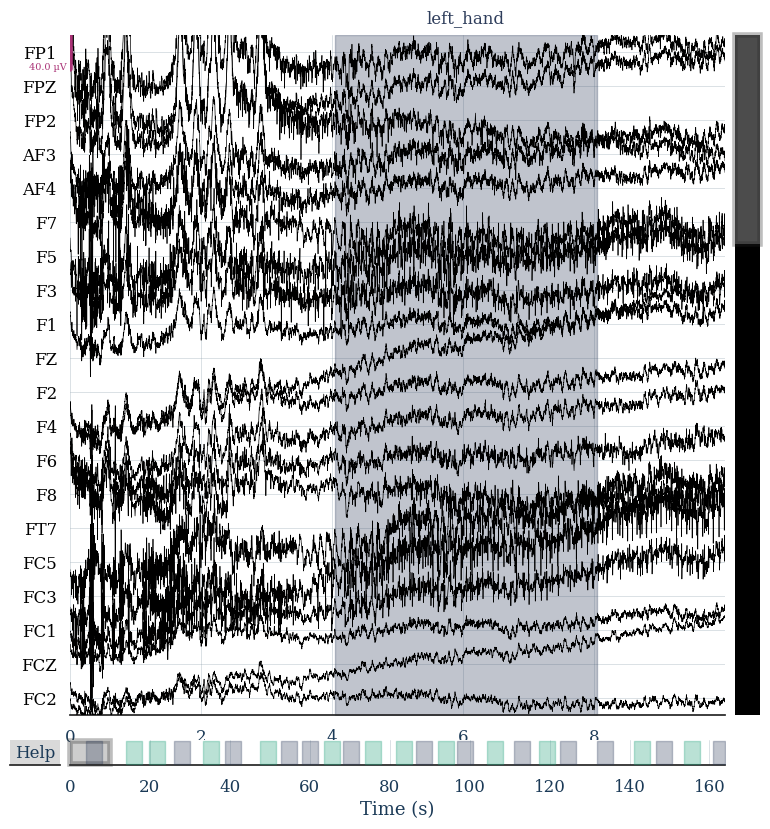

<Info | 11 non-empty values
 bads: []
 ch_names: FP1, FPZ, FP2, AF3, AF4, F7, F5, F3, F1, FZ, F2, F4, F6, F8, ...
 chs: 64 EEG, 1 Stimulus
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: 1, hand: 1>
>


In [46]:
# avoid having two plots inline
%matplotlib inline

raw.plot()
print(raw.info)

In [47]:
# have a look at annotations
print(raw.annotations)
df_annot = raw.annotations.to_data_frame()
print(df_annot)

<Annotations | 25 segments: left_hand (13), right_hand (12)>
                        onset  duration description
0  1970-01-01 00:00:04.041000  4.000000   left_hand
1  1970-01-01 00:00:14.081000  3.999999  right_hand
2  1970-01-01 00:00:19.801001  4.000000  right_hand
3  1970-01-01 00:00:26.000999  4.000000   left_hand
4  1970-01-01 00:00:33.401001  4.000000  right_hand
5  1970-01-01 00:00:38.681000  4.000000   left_hand
6  1970-01-01 00:00:47.601002  4.000000  right_hand
7  1970-01-01 00:00:52.761002  4.000000   left_hand
8  1970-01-01 00:00:58.081001  4.000000   left_hand
9  1970-01-01 00:01:03.640999  4.000000  right_hand
10 1970-01-01 00:01:08.240997  4.000000   left_hand
11 1970-01-01 00:01:13.880997  4.000000  right_hand
12 1970-01-01 00:01:21.640999  4.000000  right_hand
13 1970-01-01 00:01:26.481003  4.000000   left_hand
14 1970-01-01 00:01:32.081001  4.000000  right_hand
15 1970-01-01 00:01:36.841003  4.000000   left_hand
16 1970-01-01 00:01:44.401001  4.000000  right_hand
17 

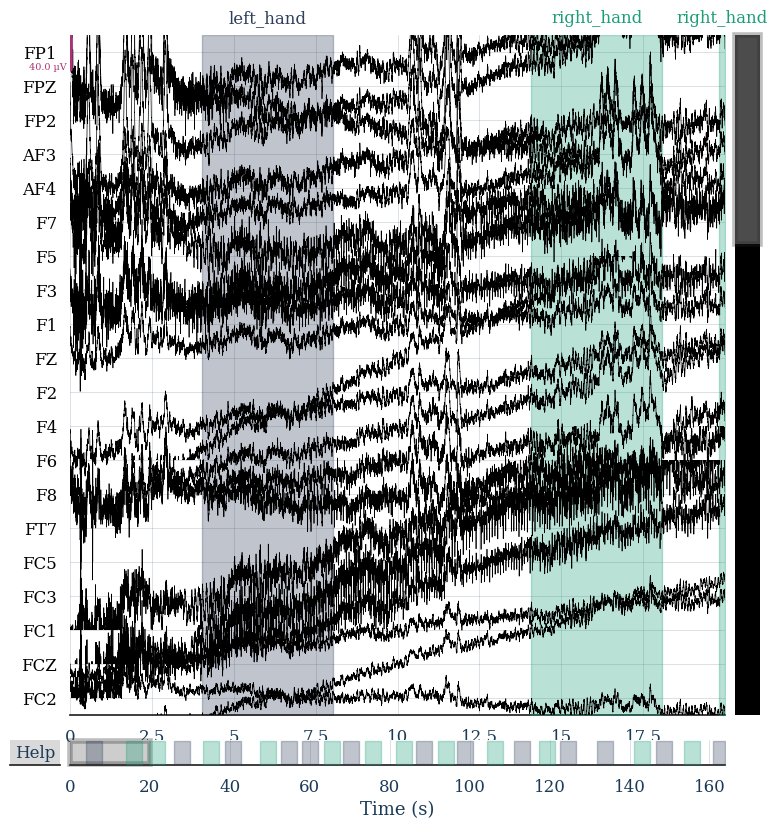

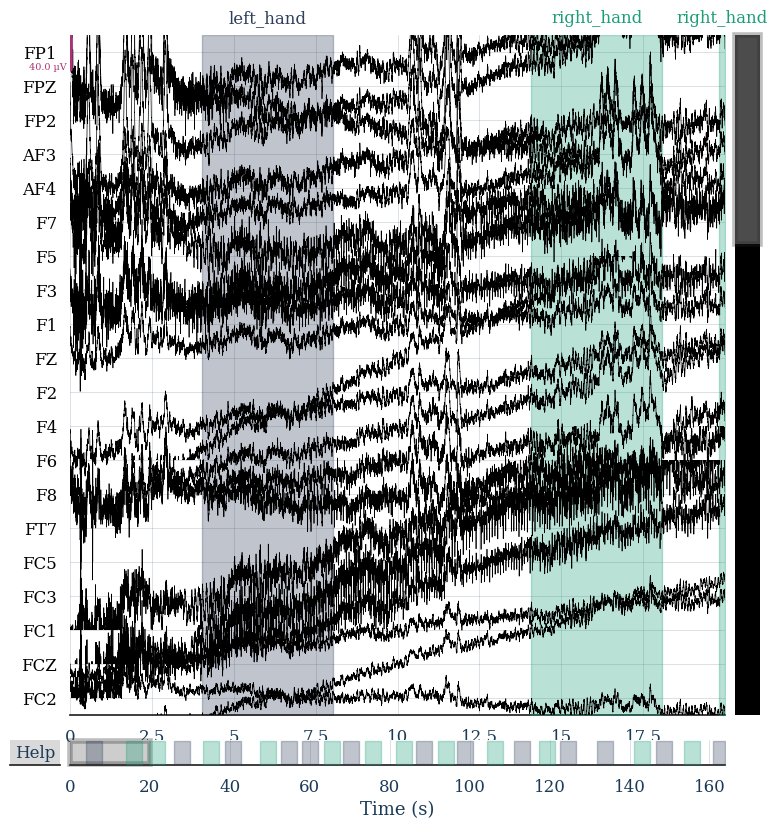

In [48]:
# 1. Minimalist Filtering
# we use l_freq=0.5 to keep it 'raw' but stable
# we use h_freq=None if you want absolute high-freqs, 
# but 45.0 is safer for ML models.
# raw.filter(l_freq=0.5, h_freq=45.0, fir_design='firwin', phase='zero')

# 2. Notch Filter (Optional but recommended for 'Raw' look)
# This removes exactly 50Hz (or 60Hz) without touching other frequencies
# raw.notch_filter(freqs=[50.0], fir_design='firwin')

# 3. Re-referencing (The most important 'minimal' step)
# This subtracts the 'average' noise from all channels.
# It doesn't change the frequency, just cleans the spatial map.
# raw.set_eeg_reference('average', projection=False)

# plot from time 0 to 10 seconds 
%matplotlib inline
raw.plot(start=0, duration=20)
# raw.plot(start=42, duration=2)

In [49]:
print(raw.ch_names)

['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2', 'STI']


In [50]:
""" extract from 0 to 58 seconds, z-score it, convert to numpy array, and save it as a .npy file """
fs = raw.info['sfreq']

new_fs = 160
# filter to new Nyquist frequency if downsampling (optional but can improve quality when downsampling)
if fs > new_fs:
    raw.filter(l_freq=0.1, h_freq=new_fs/2 - 1, fir_design='firwin', skip_by_annotation='edge', phase='zero')


# downsample to 200Hz if original sampling rate is higher (optional but can speed up processing)
if fs > new_fs:
    raw.resample(new_fs)
    fs = new_fs

# keep only eeg channels (remove STI channels)
raw.pick_types(eeg=True, stim=False)

stop_idx = int(58 * fs)  # convert 58 seconds to samples
data_array = raw.get_data(start=0, stop=stop_idx)

# z-score normalization each channel (each channel has mean 0 and std 1 across time)
data_array_zscored = (data_array - data_array.mean(axis=1, keepdims=True)) / data_array.std(axis=1, keepdims=True)

import numpy as np
np.save("Forenzo2023_subject_"+str(subject_id)+"_zscored.npy", data_array_zscored.T)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 79 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 79.00 Hz
- Upper transition bandwidth: 19.75 Hz (-6 dB cutoff frequency: 88.88 Hz)
- Filter length: 33001 samples (33.001 s)

Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
Finding events on: STI
25 events found on stim channel STI
Event IDs: [1 2]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [51]:
from scipy.signal.windows import hann
from scipy.signal import filtfilt

window_length = 15
hann_window = hann(window_length)

data_smoothed = filtfilt(hann_window, 1, data_array_zscored, axis=0)

np.save("Forenzo2023_subject_"+str(subject_id)+"_zscored_smoothed.npy", data_smoothed.T)

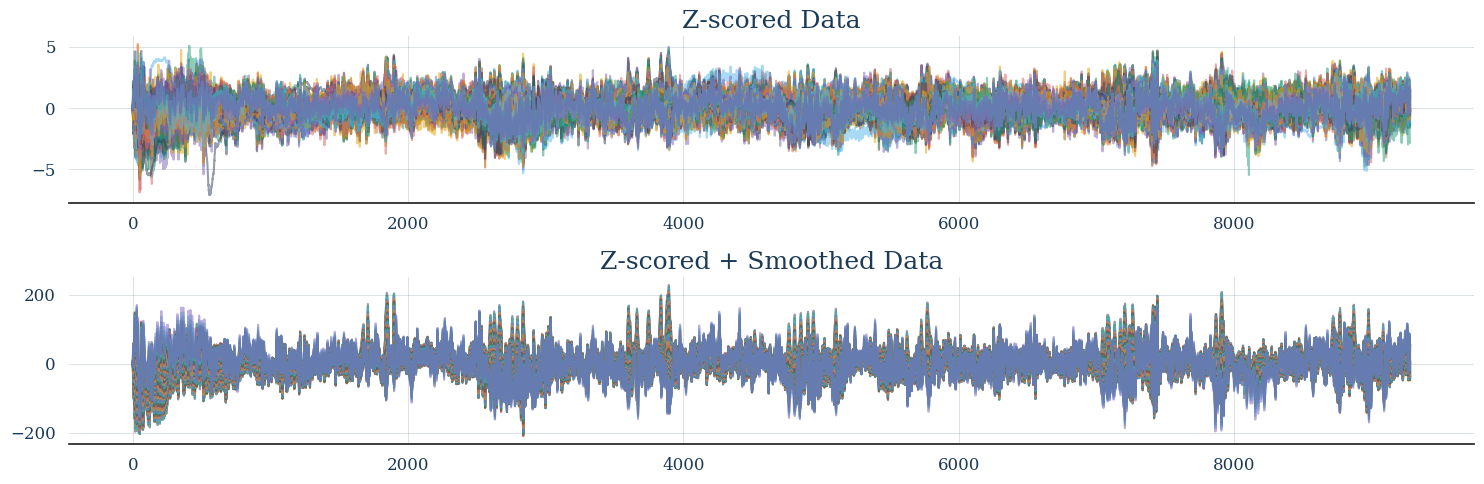

In [52]:
# vizualize data zscored and smoothed
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot( data_array_zscored.T, alpha=0.5)
plt.title("Z-scored Data")
plt.subplot(2, 1, 2)
plt.plot(data_smoothed.T, alpha=0.5)
plt.title("Z-scored + Smoothed Data")
plt.tight_layout()
plt.show()

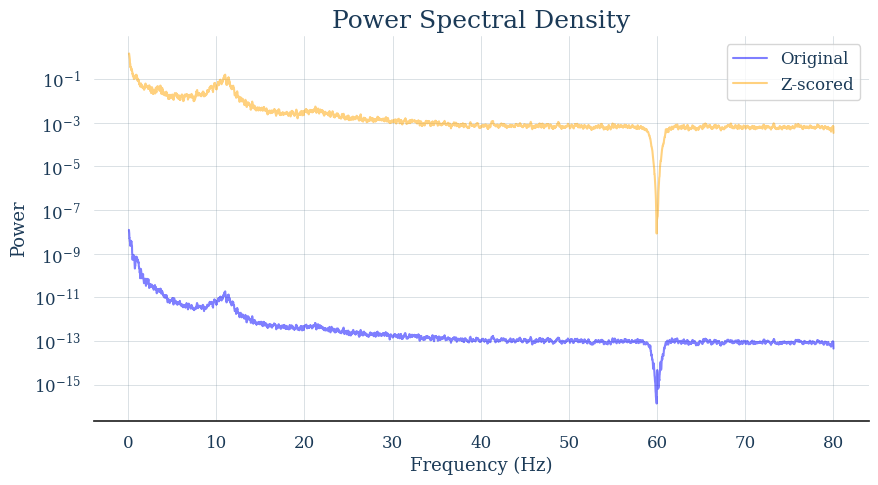

In [53]:
# get PSD of original, z-scored and then plot them
from mne.time_frequency import psd_array_multitaper
psd_original, freqs = psd_array_multitaper(data_array, sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)
psd_zscored, _ = psd_array_multitaper(data_array_zscored, sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs, np.mean(psd_original.T, axis=1), color='blue', alpha=0.5, label='Original')
plt.semilogy(freqs, np.mean(psd_zscored.T, axis=1), color='orange', alpha=0.5, label='Z-scored')
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.show()

no out nonlinearity found, setting to identity
using uniform init
Initialising VAE without encoder


Text(0.5, 1.0, 'EEG')

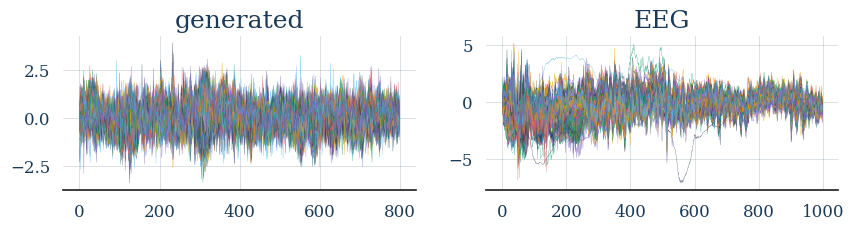

In [54]:
# have a look at the model generated data
import torch

import sys, os

sys.path.append("../")

from vi_rnn.saving import load_model
import matplotlib.pyplot as plt
from vi_rnn.generate import generate

# Load model
name = "rbm_forenzo_avg_ref_EEG_low_rank_affine_dim_z_3_date_2026_03_26_T_17_54_59"
vae, training_params, task_params = load_model(
    "../models/sweep_eeg/" + name, load_encoder=False, backward_compat=True
)


# Load data
raw_dat = data_array_zscored.T

# generate data using our fit model
Z, _, data_gen, rates_gen = generate(
    vae,
    u=None,
    x=torch.from_numpy(raw_dat.T.astype(np.float32)),
    initial_state="posterior_mean",
    k=1,
    dur=800,
)

fig, ax = plt.subplots(1, 2, figsize=(10, 2))

t = 1000
ax[0].plot(data_gen[0, :, :t, 0].T, lw=0.2, alpha=1)
ax[1].plot(raw_dat[:t], lw=0.2, alpha=1)
ax[0].set_title("generated")
ax[1].set_title("EEG")

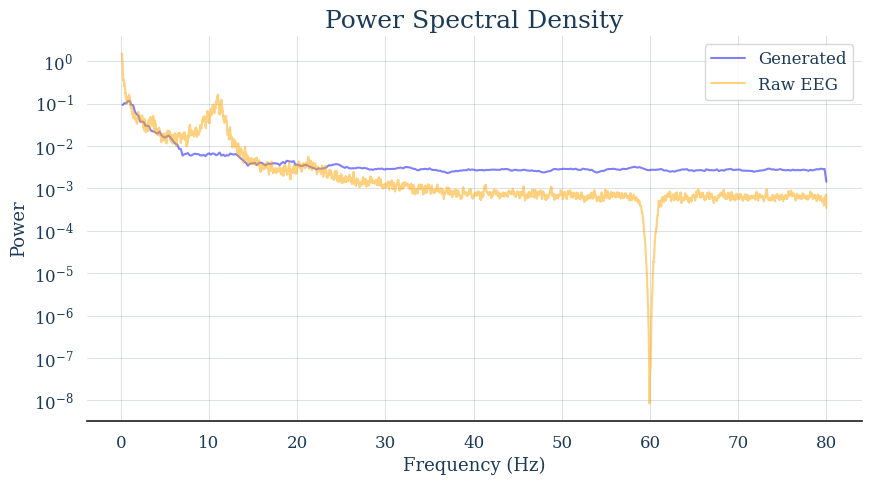

In [55]:
from mne.time_frequency import psd_array_multitaper

# plot Power spectrums of raw_dat and data_gen[0, :, :, 0].T
psd_gen, freqs_gen = psd_array_multitaper(data_gen[0, :, :, 0], sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)
psd_raw, freqs_raw = psd_array_multitaper(raw_dat.T, sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)
plt.figure(figsize=(10, 5))
plt.semilogy(freqs_gen, np.mean(psd_gen.T, axis=1), color='blue', alpha=0.5, label='Generated')
plt.semilogy(freqs_raw, np.mean(psd_raw.T, axis=1), color='orange', alpha=0.5, label='Raw EEG')
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.show()
